In [ ]:
# !wget -O asa_cw1_data.zip "https://drive.google.com/uc?export=download&id=1Lyw6VR8Z6r8DybcproNVP7dimScfglC-"

# !unzip asa_cw1_data.zip
# !ls

In [3]:
import pandas as pd
import numpy as np

customers = pd.read_csv("customers_sample.csv")
category_spends = pd.read_csv("category_spends_sample.csv")
baskets = pd.read_csv("baskets_sample.csv")
lineitems = pd.read_csv("lineitems_sample.csv")

print("customers:", customers.shape)
print("category_spends:", category_spends.shape)
print("baskets:", baskets.shape)
print("lineitems:", lineitems.shape)

customers: (3000, 6)
category_spends: (3000, 21)
baskets: (195547, 5)
lineitems: (1461315, 6)


In [4]:
display(customers.head())
display(category_spends.head())
display(baskets.head())
display(lineitems.head())

,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend
0,4749,220,260,1.181818,£631.12,£2.87
1,4757,248,333,1.342742,£452.42,£1.82
2,144,226,303,1.340708,£261.16,£1.16
3,572,285,346,1.214035,£638.79,£2.24
4,669,285,324,1.136842,£561.42,£1.97


,customer_number,fruit_veg,dairy,confectionary,grocery_food,grocery_health_pets,bakery,newspapers_magazines,prepared_meals,soft_drinks,...,meat,tobacco,drinks,deli,world_foods,lottery,cashpoint,seasonal_gifting,discount_bakery,practical_items
0,11387,£64.58,£35.91,£107.78,£27.08,£29.59,£0.00,£54.83,£6.35,£22.83,...,£28.62,£162.10,£28.02,£28.12,£28.54,£2.00,£15.00,£7.48,£0.00,£0.84
1,8171,£16.89,£37.24,£28.84,£33.43,£66.40,£0.00,£22.06,£12.09,£2.34,...,£26.44,£0.00,£8.42,£2.65,£3.76,£0.00,£0.00,£9.99,£0.00,£0.00
2,1060,£87.30,£82.98,£49.88,£20.57,£37.04,£0.00,£9.85,£57.98,£31.12,...,£54.65,£0.00,£0.00,£2.60,£0.00,£18.00,£20.00,£106.46,£0.00,£0.00
3,3728,£84.05,£186.56,£175.50,£119.84,£111.08,£0.00,£13.05,£25.54,£124.42,...,£0.95,£127.70,£0.00,£0.00,£0.00,£4.00,£0.00,£0.00,£0.00,£4.50
4,14621,£35.16,£121.31,£79.23,£29.03,£37.17,£0.00,£40.06,£0.00,£4.68,...,£36.24,£0.00,£2.55,£99.16,£0.00,£0.00,£0.00,£3.40,£0.00,£0.00


,customer_number,purchase_time,basket_quantity,basket_spend,basket_categories
0,11911,2007-03-01 07:06:00,7,£3.09,3
1,4047,2007-03-01 07:13:00,9,£7.99,5
2,3571,2007-03-01 07:27:00,9,£37.06,6
3,4079,2007-03-01 07:34:00,11,£11.91,5
4,6063,2007-03-01 07:36:00,3,£1.45,1


,customer_number,purchase_time,product_id,category,quantity,spend
0,14577,2007-03-10 11:58:00,722653,GROCERY_FOOD,1,£1.39
1,7210,2007-03-22 10:53:00,696136,GROCERY_HEALTH_PETS,1,£4.25
2,3145,2007-03-26 11:17:00,139543,GROCERY_HEALTH_PETS,1,£0.50
3,2649,2007-03-12 16:05:00,34890,BAKERY,1,£0.57
4,859,2007-03-10 09:53:00,613984,BAKERY,1,£1.59


In [5]:
def parse_pounds(series: pd.Series) -> pd.Series:       # parse £ and commas, convert to float, handle "nan" strings
    return (
        series.astype(str)
        .str.replace("£", "", regex=False)
        .str.replace(",", "", regex=False)
        .replace("nan", np.nan)
        .astype(float)
    )

customers["total_spend"] = parse_pounds(customers["total_spend"])       # total_spend column
customers["average_spend"] = parse_pounds(customers["average_spend"])       # average_spend column

baskets["basket_spend"] = parse_pounds(baskets["basket_spend"])     #basket_spend column

cat_cols = [c for c in category_spends.columns if c != "customer_number"]       # identify category columns (all except customer_number)
for c in cat_cols:
    category_spends[c] = parse_pounds(category_spends[c])    

lineitems["spend"] = parse_pounds(lineitems["spend"])       #spend column

In [6]:
baskets["purchase_time"] = pd.to_datetime(baskets["purchase_time"], errors="coerce")        #purchase_time column as datetime, coerce errors to NaT
lineitems["purchase_time"] = pd.to_datetime(lineitems["purchase_time"], errors="coerce")        

print("baskets date range:", baskets["purchase_time"].min(), "→", baskets["purchase_time"].max())

baskets date range: 2007-03-01 07:06:00 → 2007-08-31 21:55:00


## Fix bakery using lineitems

In [7]:
bakery_from_lineitems = (       # recalculate bakery spend from lineitems for discrepancies with category_spends
    lineitems.loc[lineitems["category"].astype(str).str.upper().eq("BAKERY")]
    .groupby("customer_number")["spend"]
    .sum()
    .rename("bakery_recalc")
    .reset_index()
)

category_spends = category_spends.merge(bakery_from_lineitems, on="customer_number", how="left")
category_spends["bakery_recalc"] = category_spends["bakery_recalc"].fillna(0.0)

if "bakery" in category_spends.columns:    
    category_spends["bakery"] = category_spends["bakery_recalc"]        # replace bakery column with recalculated values

category_spends.drop(columns=["bakery_recalc"], inplace=True)       # drop the recalculated column
category_spends["bakery"].describe()

count    3000.000000
mean       38.210123
std        36.496115
min         0.000000
25%        14.635000
50%        29.270000
75%        50.050000
max       444.370000
Name: bakery, dtype: float64

In [8]:
ref_date = baskets["purchase_time"].max() 

b = baskets.copy()
b["hour"] = b["purchase_time"].dt.hour
b["dow"] = b["purchase_time"].dt.dayofweek
b["is_weekend"] = (b["dow"] >= 5).astype(int)

def daypart(hour):
    if pd.isna(hour):
        return np.nan
    if hour < 12:
        return "morning"
    elif hour < 18:
        return "afternoon"
    else:
        return "evening"

b["daypart"] = b["hour"].apply(daypart)

basket_agg = b.groupby("customer_number").agg(      # aggregate features from baskets
    frequency_baskets=("purchase_time", "count"),
    monetary_basket_spend=("basket_spend", "sum"),
    avg_basket_spend=("basket_spend", "mean"),
    avg_basket_qty=("basket_quantity", "mean"),
    avg_basket_categories=("basket_categories", "mean"),
    last_purchase=("purchase_time", "max"),
    weekend_share=("is_weekend", "mean"),
)

basket_agg["recency_days"] = (ref_date - basket_agg["last_purchase"]).dt.days       # recency in days from last purchase to reference date
basket_agg.drop(columns=["last_purchase"], inplace=True)

daypart_counts = b.pivot_table(     # count of purchases by daypart for each customer
    index="customer_number",
    columns="daypart",
    values="purchase_time",
    aggfunc="count",
    fill_value=0
)

daypart_shares = daypart_counts.div(daypart_counts.sum(axis=1), axis=0).add_prefix("share_")        # convert counts to shares and prefix columns with "share_"

features_baskets = basket_agg.join(daypart_shares, how="left").fillna(0.0)
features_baskets.head()

,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,avg_basket_categories,weekend_share,recency_days,share_afternoon,share_evening,share_morning
customer_number,,,,,,,,,,
14,56,675.72,12.066429,9.482143,4.464286,0.339286,1,0.857143,0.071429,0.071429
45,33,585.73,17.749394,19.848485,6.393939,0.000000,1,0.818182,0.030303,0.151515
52,59,222.18,3.765763,4.983051,2.949153,0.016949,2,0.644068,0.000000,0.355932
61,37,547.87,14.807297,13.486486,6.027027,0.135135,3,0.891892,0.027027,0.081081
63,48,293.34,6.111250,5.854167,3.666667,0.187500,7,0.770833,0.041667,0.187500


In [9]:
cat = category_spends.copy()
cat_cols = [c for c in cat.columns if c != "customer_number"]

cat["total_category_spend"] = cat[cat_cols].sum(axis=1).replace(0, np.nan)

for c in cat_cols:
    cat[f"share_{c}"] = cat[c] / cat["total_category_spend"]

share_cols = [f"share_{c}" for c in cat_cols]
features_category = cat[["customer_number"] + share_cols].fillna(0.0)

features_category.head()

,customer_number,share_fruit_veg,share_dairy,share_confectionary,share_grocery_food,share_grocery_health_pets,share_bakery,share_newspapers_magazines,share_prepared_meals,share_soft_drinks,...,share_meat,share_tobacco,share_drinks,share_deli,share_world_foods,share_lottery,share_cashpoint,share_seasonal_gifting,share_discount_bakery,share_practical_items
0,11387,0.092553,0.051465,0.154466,0.038810,0.042407,0.038093,0.078580,0.009101,0.032719,...,0.041017,0.232315,0.040157,0.040300,0.040902,0.002866,0.021497,0.010720,0.0,0.001204
1,8171,0.045734,0.100837,0.078092,0.090520,0.179795,0.054209,0.059733,0.032737,0.006336,...,0.071593,0.000000,0.022799,0.007176,0.010181,0.000000,0.000000,0.027050,0.0,0.000000
2,1060,0.130556,0.124095,0.074595,0.030762,0.055393,0.113238,0.014731,0.086708,0.046539,...,0.081728,0.000000,0.000000,0.003888,0.000000,0.026919,0.029910,0.159209,0.0,0.000000
3,3728,0.076125,0.168970,0.158953,0.108541,0.100607,0.101141,0.011820,0.023132,0.112689,...,0.000860,0.115660,0.000000,0.000000,0.000000,0.003623,0.000000,0.000000,0.0,0.004076
4,14621,0.067042,0.231309,0.151073,0.055353,0.070874,0.063171,0.076385,0.000000,0.008924,...,0.069101,0.000000,0.004862,0.189074,0.000000,0.000000,0.000000,0.006483,0.0,0.000000


In [10]:
base = customers.copy()
base = base.merge(features_baskets.reset_index(), on="customer_number", how="left")    
base = base.merge(features_category, on="customer_number", how="left")      # merge features from baskets and category spends into base dataframe
base = base.fillna(0.0)

print("base shape:", base.shape)
base.head()

base shape: (3000, 36)


,customer_number,baskets,total_quantity,average_quantity,total_spend,average_spend,frequency_baskets,monetary_basket_spend,avg_basket_spend,avg_basket_qty,...,share_meat,share_tobacco,share_drinks,share_deli,share_world_foods,share_lottery,share_cashpoint,share_seasonal_gifting,share_discount_bakery,share_practical_items
0,4749,220,260,1.181818,631.12,2.87,92,631.12,6.860000,2.826087,...,0.003438,0.002662,0.197870,0.000000,0.000000,0.000000,0.459501,0.000000,0.000000,0.003486
1,4757,248,333,1.342742,452.42,1.82,27,452.42,16.756296,12.333333,...,0.013417,0.010300,0.048274,0.031365,0.000000,0.000000,0.000000,0.005990,0.000000,0.000000
2,144,226,303,1.340708,261.16,1.16,22,261.16,11.870909,13.772727,...,0.032049,0.000000,0.009764,0.014550,0.081100,0.000000,0.000000,0.004863,0.000000,0.000000
3,572,285,346,1.214035,638.79,2.24,40,638.79,15.969750,8.650000,...,0.032640,0.425555,0.000000,0.058032,0.017189,0.029744,0.000000,0.021776,0.009268,0.005323
4,669,285,324,1.136842,561.42,1.97,36,561.42,15.595000,9.000000,...,0.084055,0.039756,0.569164,0.000000,0.001763,0.022265,0.000000,0.005290,0.000000,0.002957


In [11]:
drop_cols = ["baskets", "total_spend", "average_spend", "total_quantity", "average_quantity"]       # Drop redundant originals from customers table
keep = base.drop(columns=[c for c in drop_cols if c in base.columns])

behaviour_features = [      # Behaviour features (include daypart shares)
    "frequency_baskets",
    "monetary_basket_spend",
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "weekend_share",
    "share_morning", "share_afternoon", "share_evening"
]

cat_share_features = [      # Category share features (exclude daypart shares)
    c for c in keep.columns
    if c.startswith("share_") and c not in ["share_morning", "share_afternoon", "share_evening"]
]

wide_features = behaviour_features + cat_share_features 
X = keep[wide_features].copy()
X["spend_per_visit"] = X["monetary_basket_spend"] / X["frequency_baskets"].replace(0, np.nan)       # Replace collinear pair with ratio 
X["spend_per_visit"] = X["spend_per_visit"].fillna(0.0)
X = X.drop(columns=["monetary_basket_spend", "frequency_baskets"], errors="ignore")

low_info_cols = [       # Drop very low-info category shares (based on your means output)
    "share_practical_items",
    "share_discount_bakery",
    "share_seasonal_gifting",
    "share_world_foods"
]
X = X.drop(columns=[c for c in low_info_cols if c in X.columns])

print("Wide X shape:", X.shape)
X.head()

Wide X shape: (3000, 25)


,avg_basket_spend,avg_basket_qty,avg_basket_categories,recency_days,weekend_share,share_morning,share_afternoon,share_evening,share_fruit_veg,share_dairy,...,share_prepared_meals,share_soft_drinks,share_frozen,share_meat,share_tobacco,share_drinks,share_deli,share_lottery,share_cashpoint,spend_per_visit
0,6.860000,2.826087,1.923913,3,0.217391,0.141304,0.326087,0.532609,0.022896,0.056424,...,0.048438,0.027538,0.016146,0.003438,0.002662,0.197870,0.000000,0.000000,0.459501,6.860000
1,16.756296,12.333333,4.148148,3,0.222222,0.185185,0.555556,0.259259,0.181712,0.359798,...,0.090403,0.041886,0.000000,0.013417,0.010300,0.048274,0.031365,0.000000,0.000000,16.756296
2,11.870909,13.772727,6.272727,3,0.000000,0.000000,1.000000,0.000000,0.135243,0.140412,...,0.054794,0.001608,0.008003,0.032049,0.000000,0.009764,0.014550,0.000000,0.000000,11.870909
3,15.969750,8.650000,4.100000,1,0.125000,0.500000,0.500000,0.000000,0.062587,0.026347,...,0.013760,0.015655,0.031074,0.032640,0.425555,0.000000,0.058032,0.029744,0.000000,15.969750
4,15.595000,9.000000,5.055556,1,0.361111,0.194444,0.611111,0.194444,0.026166,0.032792,...,0.016316,0.066528,0.008870,0.084055,0.039756,0.569164,0.000000,0.022265,0.000000,15.595000


## Preprocess: winsorise + log + scale

In [12]:
from sklearn.preprocessing import RobustScaler

X_proc = X.copy()

# Winsorisation (Outlier control) for magnitude-based features that may contain extreme values.
winsor_cols = ["avg_basket_spend", "avg_basket_qty", "avg_basket_categories", "recency_days", "spend_per_visit"]      # Winsorise at p95 for key magnitude features
for col in winsor_cols:
    if col in X_proc.columns:
        X_proc[col] = np.clip(X_proc[col], None, X_proc[col].quantile(0.95))

# reduce skewness in magnitude features.
log_cols = ["avg_basket_spend", "avg_basket_qty", "avg_basket_categories", "recency_days", "spend_per_visit"] 
for col in log_cols:
    if col in X_proc.columns:
        X_proc[col] = np.log1p(np.clip(X_proc[col], 0, None))

share_cols_all = [c for c in X_proc.columns if c.startswith("share_")] + ["weekend_share"]      # ensure no numerical errors produce invalid proportions
share_cols_all = [c for c in share_cols_all if c in X_proc.columns]
for col in share_cols_all:
    X_proc[col] = np.clip(X_proc[col], 0, 1)

scaler = RobustScaler()     # Scale features using RobustScaler to mitigate outliers
X_scaled = scaler.fit_transform(X_proc)

print("X_proc:", X_proc.shape, "X_scaled:", X_scaled.shape)

X_proc: (3000, 25) X_scaled: (3000, 25)


### RobustScaler uses median and interquartile range (IQR) instead of mean/std making it less sensitive to outliers than StandardScaler.

## PCA test loop

In [13]:
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

for n_comp in range(5, 12):
    pca = PCA(n_components=n_comp, random_state=42)     # PCA with different n_components to find good variance/silhouette balance
    X_p = pca.fit_transform(X_scaled)

    print("n_comp =", n_comp, "explained =", round(pca.explained_variance_ratio_.sum(), 3))

    for k in range(5, 8):
        km = KMeans(n_clusters=k, random_state=42, n_init=20)     # KMeans with different n_clusters to find good silhouette score
        labels = km.fit_predict(X_p)

        sil = silhouette_score(X_p, labels)
        print("   k =", k, "silhouette =", round(sil, 3))

    print()

n_comp = 5 explained = 0.778
   k = 5 silhouette = 0.334
   k = 6 silhouette = 0.329
   k = 7 silhouette = 0.333

n_comp = 6 explained = 0.811
   k = 5 silhouette = 0.31
   k = 6 silhouette = 0.311
   k = 7 silhouette = 0.305

n_comp = 7 explained = 0.837
   k = 5 silhouette = 0.284
   k = 6 silhouette = 0.283
   k = 7 silhouette = 0.279

n_comp = 8 explained = 0.86
   k = 5 silhouette = 0.26
   k = 6 silhouette = 0.259
   k = 7 silhouette = 0.256

n_comp = 9 explained = 0.879
   k = 5 silhouette = 0.243
   k = 6 silhouette = 0.241
   k = 7 silhouette = 0.234

n_comp = 10 explained = 0.894
   k = 5 silhouette = 0.232
   k = 6 silhouette = 0.23
   k = 7 silhouette = 0.223

n_comp = 11 explained = 0.909
   k = 5 silhouette = 0.22
   k = 6 silhouette = 0.217
   k = 7 silhouette = 0.16



## PCA

In [14]:
from sklearn.decomposition import PCA

n_components = 6        # n_components based on previous PCA/silhouette analysis for good variance/silhouette balance
pca = PCA(n_components=n_components, random_state=42)
X_pca = pca.fit_transform(X_scaled)

print("PCA components:", n_components)
print("Variance captured:", pca.explained_variance_ratio_.sum())
print("X_pca shape:", X_pca.shape)

PCA components: 6
Variance captured: 0.810654473206729
X_pca shape: (3000, 6)


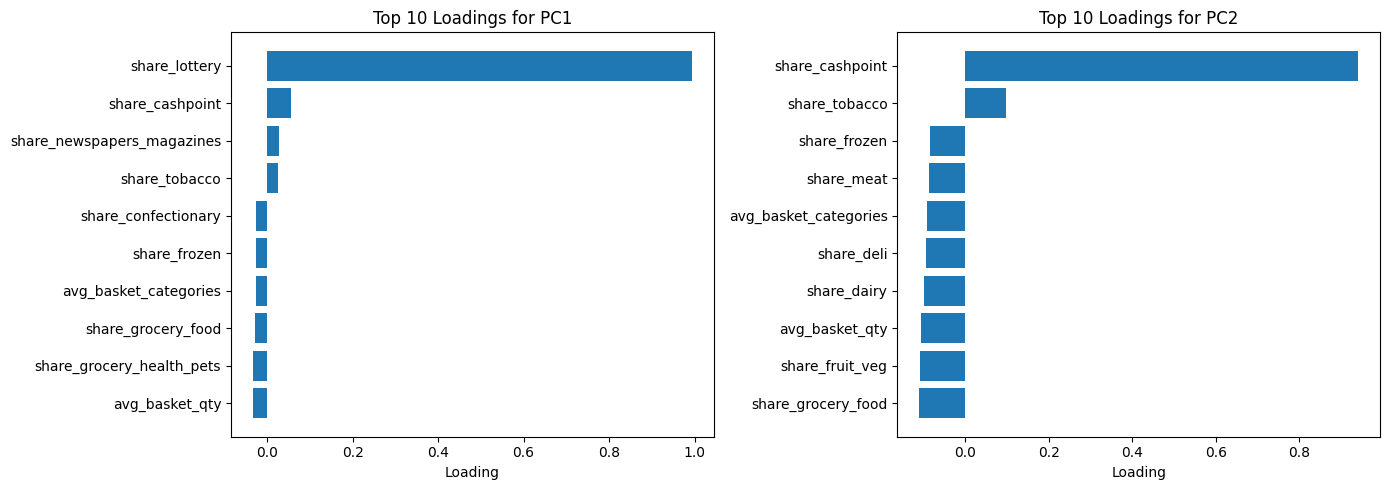

In [15]:
import matplotlib.pyplot as plt

loadings = pd.DataFrame(        # PCA loadings for original features, to interpret the principal components
    pca.components_.T,
    index=X_proc.columns,
    columns=[f"PC{i+1}" for i in range(pca.n_components_)]
)

def plot_top_loadings(pc_name, ax, top_n=10):
    s = loadings[pc_name].copy()
    top = s.abs().sort_values(ascending=False).head(top_n).index
    vals = s.loc[top].sort_values()

    ax.barh(vals.index, vals.values)
    ax.set_title(f"Top {top_n} Loadings for {pc_name}")
    ax.set_xlabel("Loading")

fig, axes = plt.subplots(1, 2, figsize=(14,5))

plot_top_loadings("PC1", axes[0], top_n=10)     # Plot top loadings for PC1 and PC2 to interpret the components
plot_top_loadings("PC2", axes[1], top_n=10)

plt.tight_layout()
plt.show()

In [16]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = range(2, 11)
rows = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=600)     # KMeans with more n_init and max_iter for stability in final clustering
    labels = km.fit_predict(X_pca)
    rows.append({
        "k": k,
        "inertia": km.inertia_,
        "silhouette": silhouette_score(X_pca, labels)
    })

k_diag = pd.DataFrame(rows)
display(k_diag)

,k,inertia,silhouette
0,2,71490.398711,0.717982
1,3,57898.263913,0.562052
2,4,46531.469456,0.451046
3,5,40949.730948,0.311017
4,6,35938.620671,0.310645
5,7,32613.428679,0.305878
6,8,29623.152578,0.309288
7,9,26684.996603,0.314893
8,10,24476.941563,0.276716


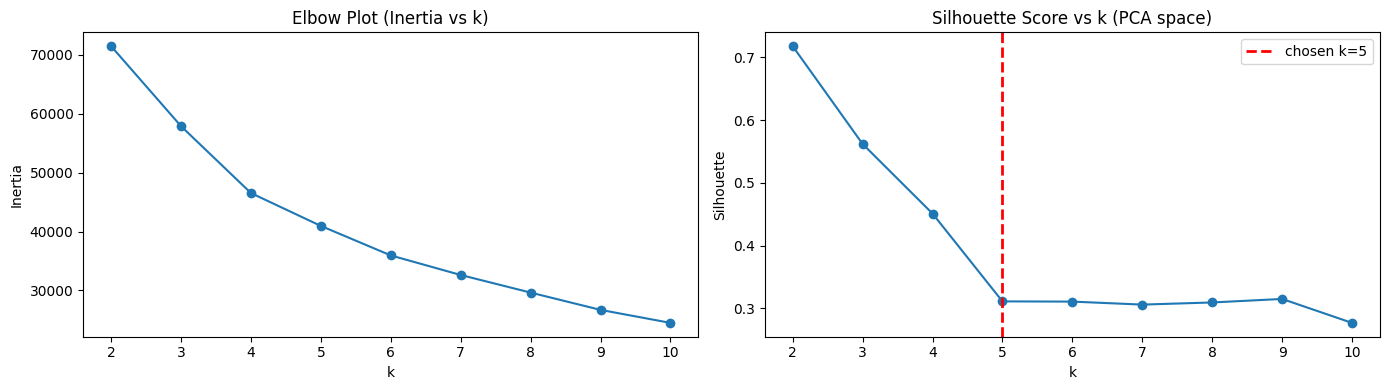

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Elbow plot (Inertia vs k)
axes[0].plot(k_diag["k"], k_diag["inertia"], marker="o")
axes[0].set_title("Elbow Plot (Inertia vs k)")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inertia")
axes[0].set_xticks(k_diag["k"])

# Silhouette score plot + chosen k=5
axes[1].plot(k_diag["k"], k_diag["silhouette"], marker="o")
axes[1].set_title("Silhouette Score vs k (PCA space)")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")
axes[1].set_xticks(k_diag["k"])

optimal_k = 5
axes[1].axvline(x=optimal_k, color="red", linestyle="--", linewidth=2, label=f"chosen k={optimal_k}")
axes[1].legend()

plt.tight_layout()
plt.show()

## KMeans for k=5..7 + choose best_k

In [18]:
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

ks = [5, 6, 7]
rows = []

for k in ks:
    km = KMeans(n_clusters=k, random_state=42, n_init=50, max_iter=600)
    labels = km.fit_predict(X_pca)
    sil = silhouette_score(X_pca, labels)
    rows.append({"k": k, "inertia": km.inertia_, "silhouette": sil})

results = pd.DataFrame(rows).sort_values("silhouette", ascending=False)
display(results)

best_k = int(results["k"].tolist()[0])

print("best_k:", best_k, type(best_k))

,k,inertia,silhouette
0,5,40949.730948,0.311017
1,6,35938.620671,0.310645
2,7,32613.428679,0.305878


best_k: 5 <class 'int'>


In [19]:
from sklearn.metrics import adjusted_rand_score     # Adjusted Rand Index to compare clusterings from different random seeds for stability

seeds = [0, 1, 2, 3, 4]
labels_by_seed = []

for s in seeds:
    km = KMeans(n_clusters=best_k, random_state=s, n_init=50, max_iter=600)
    labels_by_seed.append(km.fit_predict(X_pca))

aris = []       # # Compare all pairs
for i in range(len(seeds)):
    for j in range(i+1, len(seeds)):
        aris.append(adjusted_rand_score(labels_by_seed[i], labels_by_seed[j]))

aris_arr = np.array(aris)
print("ARI mean:", round(float(np.mean(aris_arr)), 3), "min:", round(float(np.min(aris_arr)), 3))


ARI mean: 0.991 min: 0.98


### The clustering solution showed extremely high stability (mean ARI = 0.991, minimum ARI = 0.98), indicating that the resulting cluster assignments were highly consistent across runs

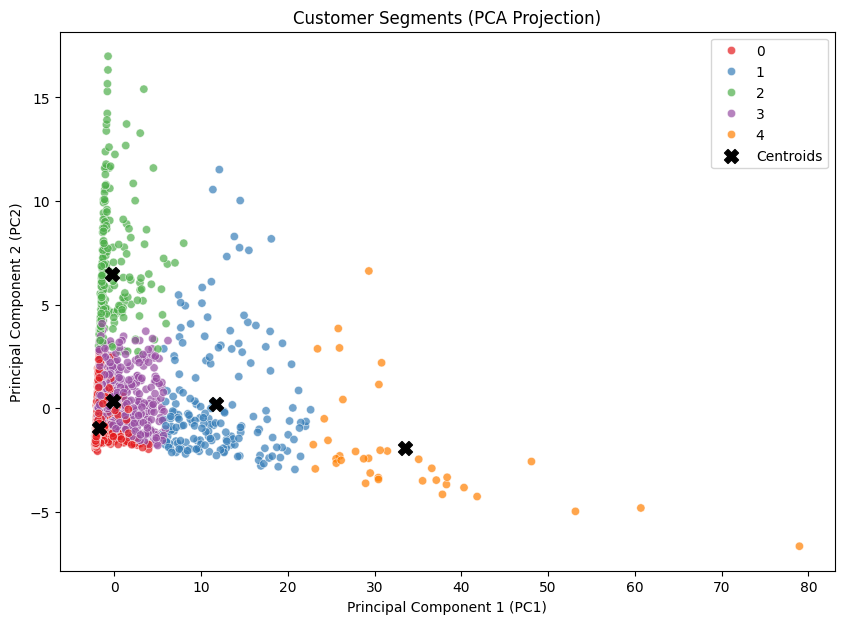

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans

km = KMeans(n_clusters=best_k, random_state=42, n_init=50, max_iter=600)
labels = km.fit_predict(X_pca)
centroids = km.cluster_centers_


plt.figure(figsize=(10, 7))
sns.scatterplot(
    x=X_pca[:,0],      # Principal Component 1
    y=X_pca[:,1],      # Principal Component 2
    hue=labels,        
    palette="Set1",    
    alpha=0.7          
)
plt.scatter(
    centroids[:,0],    # Centroid PC1 coordinate
    centroids[:,1],    # Centroid PC2 coordinate
    c="black",
    s=100,             
    marker="X",        
    label="Centroids"
)
plt.title("Customer Segments (PCA Projection)")
plt.xlabel("Principal Component 1 (PC1)")
plt.ylabel("Principal Component 2 (PC2)")
plt.legend()
plt.show()

In [21]:
final_km = KMeans(n_clusters=best_k, random_state=42, n_init=50, max_iter=600)
segment_idx = final_km.fit_predict(X_pca)       # Final cluster assignments for the best k, to create segment labels

seg = keep[["customer_number"]].copy()
seg["segment_id"] = segment_idx + 1
seg["segment_name"] = seg["segment_id"].apply(lambda x: f"cluster {x}")

seg.head()

,customer_number,segment_id,segment_name
0,4749,3,cluster 3
1,4757,1,cluster 1
2,144,1,cluster 1
3,572,4,cluster 4
4,669,4,cluster 4


In [22]:
segment_sizes = (
    seg["segment_name"]
    .value_counts()
    .rename_axis("segment_name")
    .reset_index(name="n_customers")
)

segment_sizes["pct_customers"] = segment_sizes["n_customers"] / segment_sizes["n_customers"].sum()
segment_sizes

,segment_name,n_customers,pct_customers
0,cluster 1,1824,0.608000
1,cluster 4,716,0.238667
2,cluster 3,244,0.081333
3,cluster 2,179,0.059667
4,cluster 5,37,0.012333


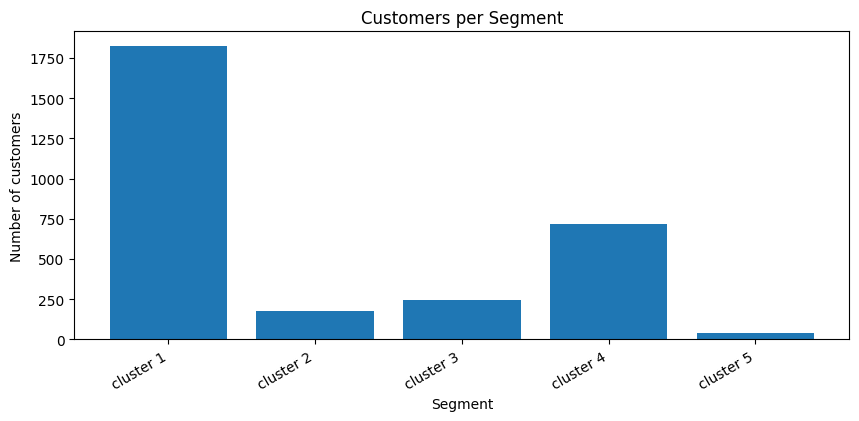

In [23]:
segment_counts = seg["segment_name"].value_counts().sort_index()        # Count customers per segment for plotting, sort by segment name for consistent order

x = segment_counts.index.to_numpy()
h = segment_counts.to_numpy(dtype=float)

plt.figure(figsize=(10,4))
plt.bar(x, h)
plt.title("Customers per Segment")
plt.xlabel("Segment")
plt.ylabel("Number of customers")
plt.xticks(rotation=30, ha="right")
plt.show()

In [24]:
profile_df = keep.merge(seg, on="customer_number", how="left")

key_features = [
    "avg_basket_spend",
    "avg_basket_qty",
    "avg_basket_categories",
    "recency_days",
    "weekend_share",
    "share_morning", "share_afternoon", "share_evening"
]

summary_means = profile_df.groupby("segment_name")[key_features].mean().round(3)        # Summary of mean values of key features by segment to interpret segment profiles
summary_medians = profile_df.groupby("segment_name")[key_features].median().round(3)    

display(summary_means)
display(summary_medians)

,avg_basket_spend,avg_basket_qty,avg_basket_categories,recency_days,weekend_share,share_morning,share_afternoon,share_evening
segment_name,,,,,,,,
cluster 1,16.769,14.037,5.262,9.044,0.231,0.353,0.551,0.096
cluster 2,10.211,6.905,3.849,5.352,0.249,0.389,0.507,0.104
cluster 3,12.636,6.866,3.799,6.865,0.226,0.342,0.528,0.130
cluster 4,11.846,7.070,3.806,7.110,0.234,0.302,0.534,0.164
cluster 5,11.452,6.568,3.709,3.811,0.201,0.438,0.433,0.129


,avg_basket_spend,avg_basket_qty,avg_basket_categories,recency_days,weekend_share,share_morning,share_afternoon,share_evening
segment_name,,,,,,,,
cluster 1,13.136,11.319,5.035,2.0,0.208,0.269,0.583,0.034
cluster 2,9.144,6.291,3.818,1.0,0.250,0.372,0.512,0.039
cluster 3,11.626,6.328,3.684,1.0,0.218,0.279,0.545,0.068
cluster 4,10.453,6.421,3.691,1.0,0.232,0.218,0.551,0.086
cluster 5,8.734,5.429,3.387,1.0,0.196,0.376,0.433,0.036


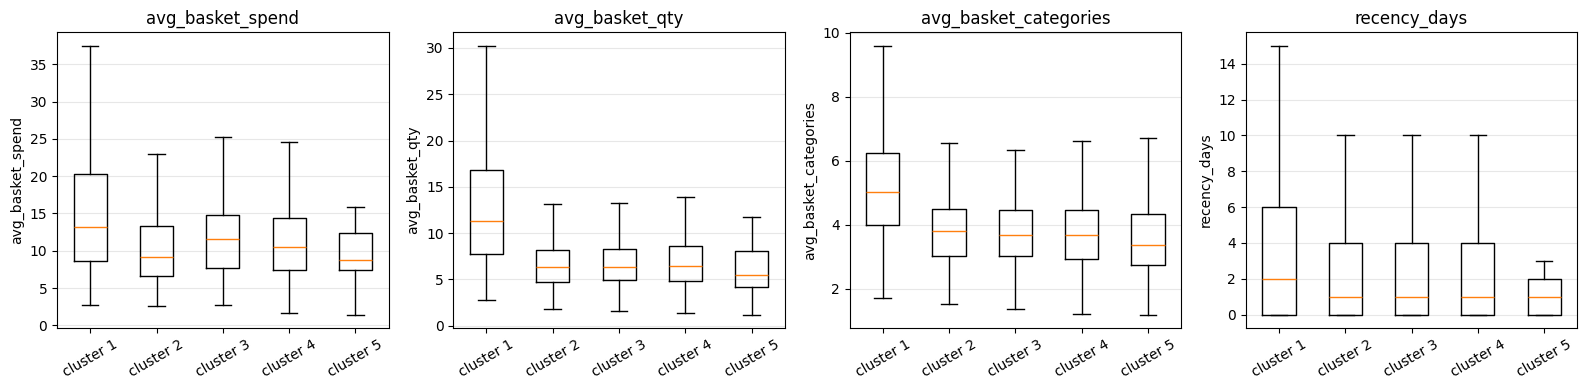

In [25]:
import matplotlib.pyplot as plt

key_features = ["avg_basket_spend", "avg_basket_qty", "avg_basket_categories", "recency_days"]

fig, axes = plt.subplots(1, len(key_features), figsize=(16,4), sharex=False)        # Boxplots of key features by segment to visualize distributions and differences between segments

for ax, col in zip(axes, key_features):
    data = []
    labels = []
    
    for seg_name, g in profile_df.groupby("segment_name"):
        data.append(g[col].values)
        labels.append(seg_name)

    ax.boxplot(data, tick_labels=labels, showfliers=False)
    ax.set_title(col)
    ax.set_ylabel(col)
    ax.tick_params(axis="x", rotation=30)
    ax.grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

In [26]:
from scipy.stats import f_oneway

profile_df = keep.merge(seg, on="customer_number", how="left")

test_cols = ["avg_basket_spend", "avg_basket_qty", "avg_basket_categories", "recency_days"]     # ANOVA tests to check if means of key features differ significantly

for col in test_cols:
    groups = [g[col].values for _, g in profile_df.groupby("segment_name")]
    f, p = f_oneway(*groups)
    print(col, "p-value:", f"{p:.3e}")

avg_basket_spend p-value: 3.773e-32
avg_basket_qty p-value: 8.725e-114
avg_basket_categories p-value: 2.767e-126
recency_days p-value: 2.895e-02


### The ANOVA results show that all behavioural metrics have significantly different means across the customer segments (p < 0.05), indicating that the segments represent distinct customer behaviours.

## Top 5 category preferences per segment

In [27]:
cat_share_cols = [
    c for c in profile_df.columns
    if c.startswith("share_") and c not in ["share_morning", "share_afternoon", "share_evening"]
]

seg_cat_means = profile_df.groupby("segment_name")[cat_share_cols].mean()

for seg_name in seg_cat_means.index:    
    top5 = seg_cat_means.loc[seg_name].sort_values(ascending=False).head(5)
    print("\nSegment:", seg_name)
    print("------------------------")
    for category, value in top5.items():
        print(category.replace("share_", ""), ":", round(value, 3))


Segment: cluster 1
------------------------
fruit_veg : 0.12
dairy : 0.118
grocery_food : 0.101
grocery_health_pets : 0.097
confectionary : 0.096

Segment: cluster 2
------------------------
tobacco : 0.143
lottery : 0.123
cashpoint : 0.093
dairy : 0.08
fruit_veg : 0.069

Segment: cluster 3
------------------------
cashpoint : 0.36
tobacco : 0.096
dairy : 0.066
confectionary : 0.062
grocery_health_pets : 0.051

Segment: cluster 4
------------------------
tobacco : 0.266
drinks : 0.157
dairy : 0.07
fruit_veg : 0.058
grocery_health_pets : 0.056

Segment: cluster 5
------------------------
lottery : 0.323
tobacco : 0.12
cashpoint : 0.065
drinks : 0.062
dairy : 0.058


## Attractiveness ranking - Segments were ranked by attractiveness based on how valuable and active the customers in each segment are.

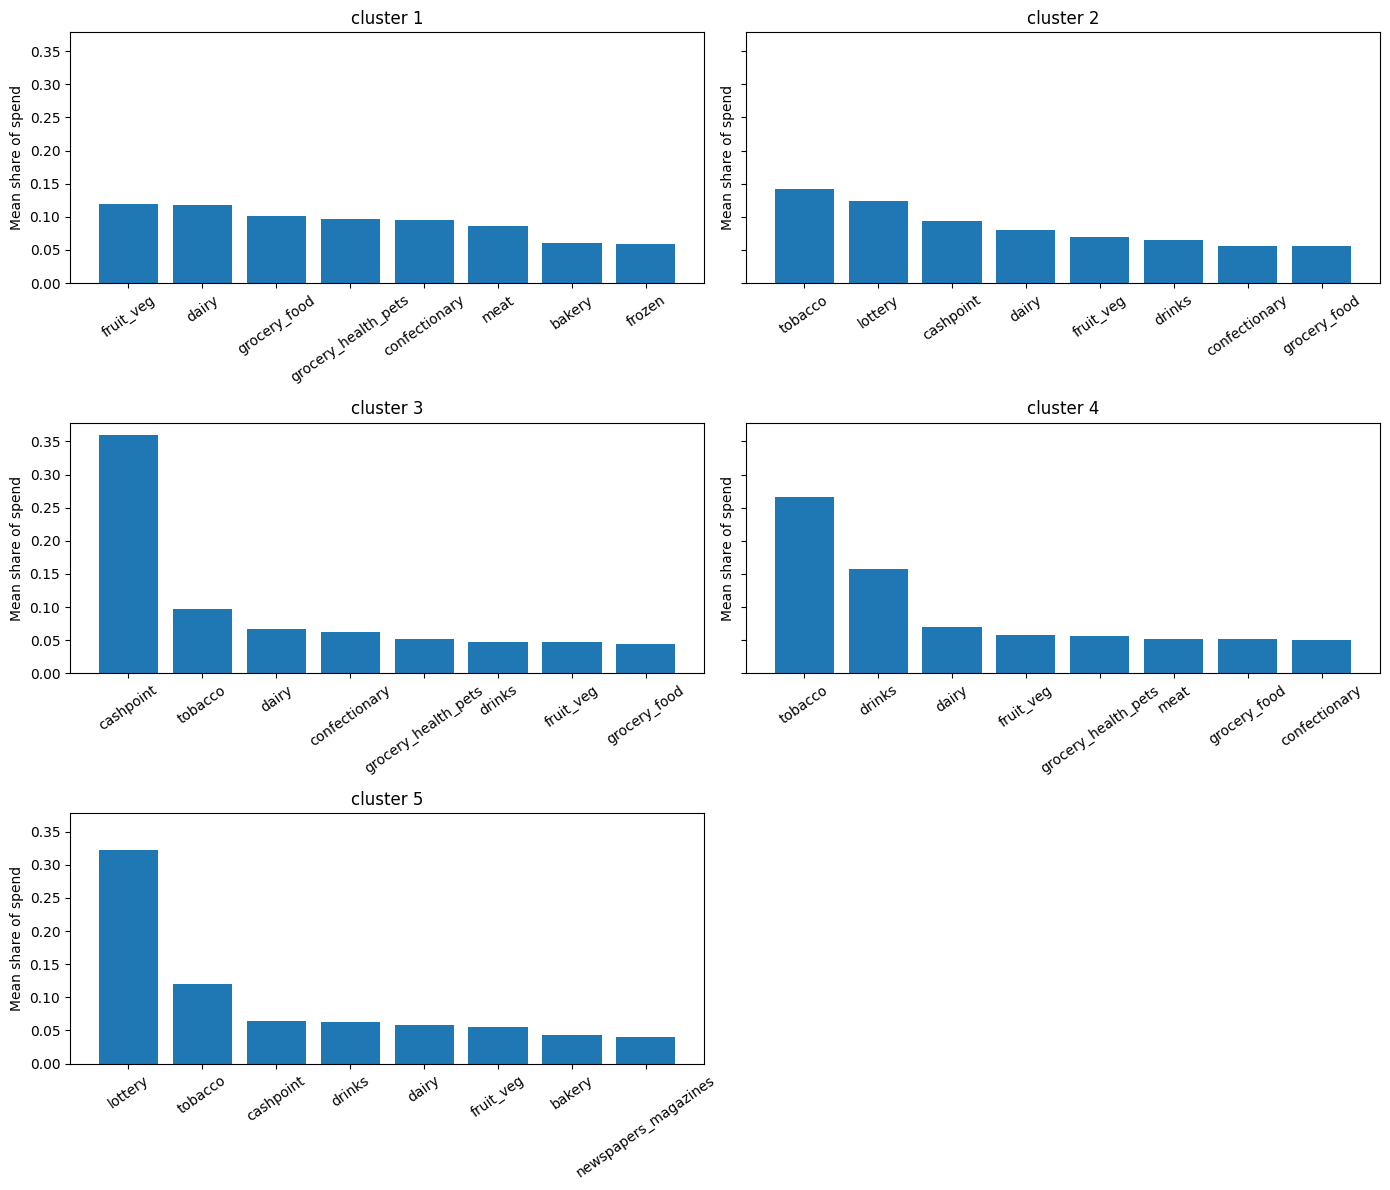

In [28]:
import matplotlib.pyplot as plt
import math

cat_share_cols = [c for c in profile_df.columns 
                  if c.startswith("share_") and c not in ["share_morning","share_afternoon","share_evening"]]       # Identify category share columns (exclude daypart shares)

seg_cat_means = profile_df.groupby("segment_name")[cat_share_cols].mean()       # shows typical category preferences for each customer segment

n_segments = len(seg_cat_means)  
ncols = 2
nrows = math.ceil(n_segments / ncols)

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 4*nrows), sharey=True)
axes = axes.flatten()

for ax, seg_name in zip(axes, seg_cat_means.index):
    top = seg_cat_means.loc[seg_name].sort_values(ascending=False).head(8)

    ax.bar(top.index.str.replace("share_", ""), top.values)
    ax.set_title(seg_name)
    ax.set_ylabel("Mean share of spend")
    ax.tick_params(axis="x", rotation=35)

# Hide any unused subplots
for i in range(len(seg_cat_means), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout()
plt.show()

In [29]:
seg_kpis = profile_df.groupby("segment_name").agg(
    n_customers=("customer_number", "count"),
    mean_avg_basket_spend=("avg_basket_spend", "mean"),
    mean_recency=("recency_days", "mean")
).reset_index()

def minmax(s):      # Min-max normalization function to scale features between 0 and 1 for attractiveness scoring
    if s.max() == s.min():
        return np.zeros_like(s, dtype=float)
    return (s - s.min()) / (s.max() - s.min())

tmp = seg_kpis.copy()
tmp["value_norm"] = minmax(tmp["mean_avg_basket_spend"])          # Normalise average basket spend (higher spend = more attractive)
tmp["recency_norm"] = 1 - minmax(tmp["mean_recency"])            # Normalise recency (lower recency = better, meaning customers purchased more recently)

w_value, w_rec = 0.7, 0.3       # Weights for value and recency in attractiveness score, based on business judgement that value is more important but recency also matters
tmp["attractiveness_score"] = w_value * tmp["value_norm"] + w_rec * tmp["recency_norm"]

seg_ranking = tmp.sort_values("attractiveness_score", ascending=False)
seg_ranking

,segment_name,n_customers,mean_avg_basket_spend,mean_recency,value_norm,recency_norm,attractiveness_score
0,cluster 1,1824,16.769294,9.043860,1.000000,0.000000,0.700000
4,cluster 5,37,11.452267,3.810811,0.189277,1.000000,0.432494
2,cluster 3,244,12.636261,6.864754,0.369809,0.416412,0.383790
3,cluster 4,716,11.845655,7.110335,0.249260,0.369483,0.285327
1,cluster 2,179,10.210916,5.351955,0.000000,0.705498,0.211649


## Export required CSV

In [30]:
output_path = "customer_segments_ASA_BUSI4370_20811152.csv"
seg.sort_values("customer_number").to_csv(output_path, index=False)
output_path

'customer_segments_ASA_BUSI4370_20811152.csv'

In [31]:
df = pd.read_csv("customer_segments_ASA_BUSI4370_20811152.csv")
segments = df.groupby("segment_name")["customer_number"].apply(list)
print(segments)

segment_name
cluster 1    [14, 45, 52, 61, 63, 67, 68, 71, 77, 81, 83, 1...
cluster 2    [133, 176, 263, 305, 412, 732, 792, 838, 896, ...
cluster 3    [236, 258, 280, 308, 398, 521, 550, 616, 620, ...
cluster 4    [85, 108, 342, 401, 409, 427, 433, 445, 507, 5...
cluster 5    [1935, 2359, 2476, 2669, 3711, 3781, 4166, 424...
Name: customer_number, dtype: object
